In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp
from utils import *
from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2025-05-13 11:05:23.604623: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-13 11:05:23.849368: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-13 11:05:23.849400: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-13 11:05:23.888156: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-13 11:05:23.965552: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model
def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result

In [ ]:
dataset_id = 'ascad-variable'
resample_window=80
traces_dim = 2000

n_prof= 100000
import gc

lm = "ID"
target_byte = 2
path = "./datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)

# Initialize SBox in objects as these are not loaded in default dataset.
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


## Training model and plotting PI evolution

In [4]:
import gc

n_epochs = 200
batch_size=400
model = mlp(256,traces_dim)
# Prefix for model loading. 
model_name = f"mlp_ascadr"


2025-05-13 11:05:46.173459: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 2000)]            0         
                                                                 
 dense (Dense)               (None, 100)               200100    
                                                                 
 dense_1 (Dense)             (None, 100)               10100     
                                                                 
 dense_2 (Dense)             (None, 100)               10100     
                                                                 
 dense_3 (Dense)             (None, 100)               10100     
                                                                 
 dense_4 (Dense)             (None, 100)               10100     
                                                                 
 dense_5 (Dense)             (None, 100)               

2025-05-13 11:05:46.295083: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-13 11:05:46.295125: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-13 11:05:46.296519: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-13 11:05:46.296550: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-13 11:05:46.296570: I external/local_xla/xla/stream_executor

In [ ]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    # Reload the model and its weights
    #layer = layers
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")

    # Extract the outputs of all layers and store them in tmp/tmp_att
    outputs = [model.layers[layer].output if layer > 0 else [] for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()

# Reload the model and its weights if only output is needed (e.g., for model evaluation)
def only_reload(epoch):
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")
probes_for_bit = []

# Code to automatically retrain probes for each bit of the SBox input and output

def retrain_probes_per_bit(epochs=5):
    global probes_for_bit 
    probes_for_bit = []
    # Train the probes on layer before output layer
    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[-2],(dataset.profiling_labels.astype(np.uint8)>>k)&0x1, epochs=epochs)
        probes_for_bit.append(probe_for_sbox_input)

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[-2],(sbox_ins>>k)&0x1, epochs=epochs)
        probes_for_bit.append(probe_for_sbox_input)

# Computing accuracies of the probes
def probe_accuracies():
    probe_accuracies = []
    for k in range(8):

        bit_points = (dataset.attack_labels.astype(np.uint8)>>k)&0x1
        probe_accuracies.append(np.sum(np.argmax(probes_for_bit[k].predict(tmp_att[-2][:10000]), axis=1) ==bit_points)/10000)

    for k in range(8):

        bit_points = (sbox_ins_att>>k)&0x1
        probe_accuracies.append(np.sum(np.argmax(probes_for_bit[k+8].predict(tmp_att[-2][:10000]), axis=1) ==bit_points)/10000)
    return probe_accuracies



In [6]:
training = False
pi_prof, pi_attack = [], []


if not training:
    # Only reload the model for generating PI plots
    for i in range(n_epochs):

        only_reload(i+1)
        pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
        pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
        print(i, pi_prof[-1], pi_attack[-1])
        gc.collect()
else:
    # Train the model
    for i in range(n_epochs):
            model.fit(
            x=dataset.x_profiling,
            y=to_categorical(dataset.profiling_labels, num_classes=dataset.classes),
            batch_size=batch_size,
            verbose=2,
            epochs=1,
            shuffle=True)
            model.save_weights(f"model_checkpoints/{model_name}_{(i+1):02d}.weights.h5")
            #only_reload(i+1)
            pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
            pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
            print(i, pi_prof[-1], pi_attack[-1])
            gc.collect()

 56/313 [====>.........................] - ETA: 0s

2025-05-13 11:05:55.958286: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


313/313 [==============================] - 0s 1ms/step
0 -0.01867069007179242 -0.02085162131673613


313/313 [==============================] - 0s 1ms/step
1 -0.017277339852067433 -0.020504415201010987


313/313 [==============================] - 0s 1ms/step
2 -0.01755185157081967 -0.020893160318208037


...

313/313 [==============================] - 0s 1ms/step
96 4.616219590079569 2.413814417196442


313/313 [==============================] - 0s 1ms/step
97 4.645849564444806 2.4136118560087003


313/313 [==============================] - 0s 1ms/step
98 4.663609397208477 2.38193624260538


313/313 [==============================] - 0s 1ms/step
99 4.674611422812731 2.3646406790983057


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'model_checkpoints/mlp_ascadr_101.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [8]:
probe_total = np.zeros((100, 16))
# Reload the model and retrain probes for each 10 epochs
# and compute the probe accuracies (this takes a while if done for all epochs)
for i in range(0, 100,10):
    
    reload_model(i+1)
    retrain_probes_per_bit(epochs=5)

    probe_total[i] = probe_accuracies()
    gc.collect()
    print(probe_total[i])
    print("Probe accuracies for epoch", i+1)

313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5004
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5001
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5011
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5016
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5032
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.4971
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5017
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.4992
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.4988
Epoch 2/2
250/250 [==============================] - 1

[0.4967 0.509  0.5084 0.498  0.4993 0.4982 0.5059 0.4993 0.4923 0.5011
 0.5009 0.5058 0.5022 0.5067 0.5049 0.5016]
Probe accuracies for epoch 2
313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6897 - accuracy: 0.5430
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6864 - accuracy: 0.5487
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7114 - accuracy: 0.5276
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6888 - accuracy: 0.5364
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7075 - accuracy: 0.5198
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6902 - accuracy: 0.5360
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7178 - accuracy: 0.5182
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6911 - accuracy: 0.5316
Epoch 1/2

[0.5393 0.5351 0.5393 0.5444 0.5197 0.514  0.5479 0.5237 0.7205 0.7798
 0.51   0.5214 0.5005 0.5018 0.5012 0.5113]
Probe accuracies for epoch 12
313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.4141 - accuracy: 0.7990
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3504 - accuracy: 0.8264
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5934 - accuracy: 0.7024
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.4503 - accuracy: 0.7782
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7642 - accuracy: 0.5223
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6956 - accuracy: 0.5347
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7549 - accuracy: 0.5312
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6875 - accuracy: 0.5538
Epoch 1/

[0.8161 0.7701 0.5401 0.5541 0.5453 0.5283 0.5403 0.5368 0.8281 0.8864
 0.5284 0.5267 0.5169 0.5437 0.5211 0.5312]
Probe accuracies for epoch 22
313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.3961 - accuracy: 0.8142
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3147 - accuracy: 0.8481
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5729 - accuracy: 0.7302
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.4050 - accuracy: 0.8081
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7864 - accuracy: 0.5224
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7021 - accuracy: 0.5316
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7549 - accuracy: 0.5288
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6888 - accuracy: 0.5549
Epoch 1/

[0.8272 0.7942 0.5301 0.5588 0.5462 0.5283 0.5421 0.5388 0.8418 0.8908
 0.5535 0.5347 0.531  0.5364 0.5243 0.5443]
Probe accuracies for epoch 32
313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.4134 - accuracy: 0.8217
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.2842 - accuracy: 0.8656
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5349 - accuracy: 0.7387
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3753 - accuracy: 0.8226
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8180 - accuracy: 0.5177
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.7009 - accuracy: 0.5363
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8385 - accuracy: 0.5322
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6928 - accuracy: 0.5634
Epoch 1/

[0.8343 0.8016 0.5462 0.5562 0.5407 0.5393 0.5456 0.553  0.8411 0.8942
 0.5492 0.5546 0.5343 0.5453 0.5435 0.566 ]
Probe accuracies for epoch 42
313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.2900 - accuracy: 0.8632
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.2565 - accuracy: 0.8811
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5494 - accuracy: 0.7418
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3613 - accuracy: 0.8308
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8384 - accuracy: 0.5284
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6962 - accuracy: 0.5558
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8527 - accuracy: 0.5458
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6893 - accuracy: 0.5696
Epoch 1/

[0.8431 0.8029 0.5481 0.5667 0.5542 0.5566 0.5638 0.5625 0.8352 0.8972
 0.5618 0.5691 0.5387 0.5648 0.5548 0.5691]
Probe accuracies for epoch 52
313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5168 - accuracy: 0.8027
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.2629 - accuracy: 0.8774
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7371 - accuracy: 0.7135
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3529 - accuracy: 0.8345
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8677 - accuracy: 0.5256
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7019 - accuracy: 0.5569
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7932 - accuracy: 0.5491
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6783 - accuracy: 0.5797
Epoch 1/

[0.8349 0.8014 0.5609 0.5696 0.5534 0.5598 0.5578 0.5665 0.8329 0.8926
 0.5484 0.5929 0.5466 0.5709 0.5585 0.5686]
Probe accuracies for epoch 62
313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.3711 - accuracy: 0.8403
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.2613 - accuracy: 0.8802
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5523 - accuracy: 0.7523
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.3567 - accuracy: 0.8353
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8368 - accuracy: 0.5331
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6989 - accuracy: 0.5647
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8284 - accuracy: 0.5378
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6799 - accuracy: 0.5775
Epoch 1/

[0.8366 0.7992 0.558  0.5701 0.5672 0.5549 0.5567 0.5771 0.8345 0.8907
 0.5643 0.5951 0.5432 0.5733 0.5599 0.5626]
Probe accuracies for epoch 72
313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.3094 - accuracy: 0.8627
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.2388 - accuracy: 0.8916
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9269 - accuracy: 0.6801
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.3786 - accuracy: 0.8216
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8984 - accuracy: 0.5406
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6955 - accuracy: 0.5723
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9380 - accuracy: 0.5420
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6818 - accuracy: 0.5847
Epoch 1/

KeyboardInterrupt: 

[[0.     0.     0.     ... 0.     0.     0.    ]
 [0.4967 0.509  0.5084 ... 0.5067 0.5049 0.5016]
 [0.     0.     0.     ... 0.     0.     0.    ]
 ...
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]]


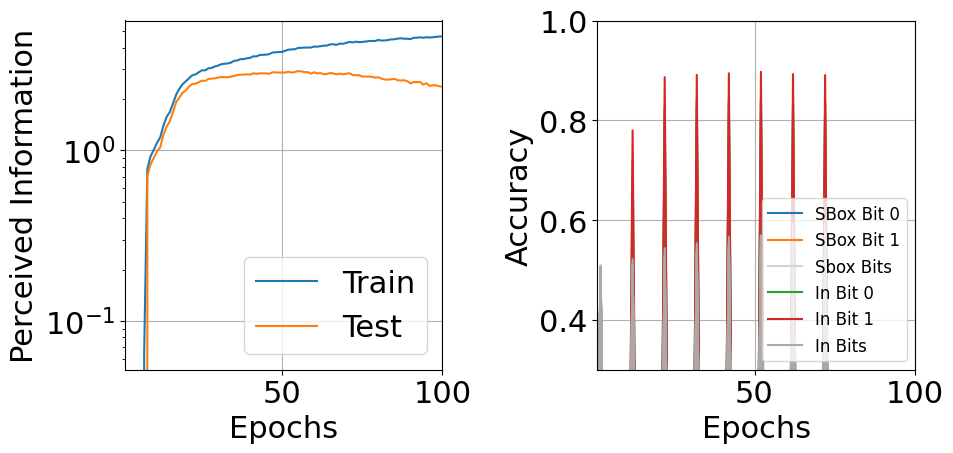

In [9]:
import gc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(range(1, 101), pi_prof, label="Train")
plt.plot(range(1, 101), pi_attack, label="Test")


plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.xlim([1,100])
plt.grid()
plt.legend()
plt.subplot(1,2,2)
print(probe_total)
for i in range(16):
    if i % 8 < 2:
        if i > 7:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], label=f"In Bit {i%8}")
        else:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], label=f"SBox Bit {i%8}")
    
    else:
        if i ==2:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], color='lightgrey', label="Sbox Bits")
        elif i < 8:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], color='lightgrey')
        elif i == 10:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], color='darkgrey', label="In Bits")
        else:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], color='darkgrey')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim([0.3, 1.0])
plt.grid()
plt.xlim([1, 100])
plt.legend(loc=4, prop={'size': 12})
plt.tight_layout()
plt.savefig("ascadr_cnn_pi_acc.png", dpi=100)


## Logit Visualization

## Plot logits per class

2/2 [==============================] - 0s 2ms/step


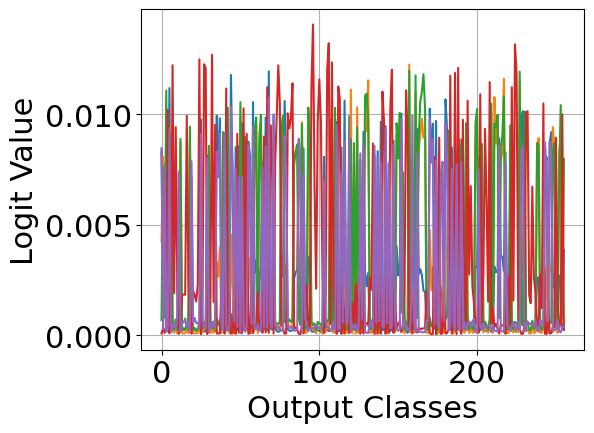

2/2 [==============================] - 0s 2ms/step


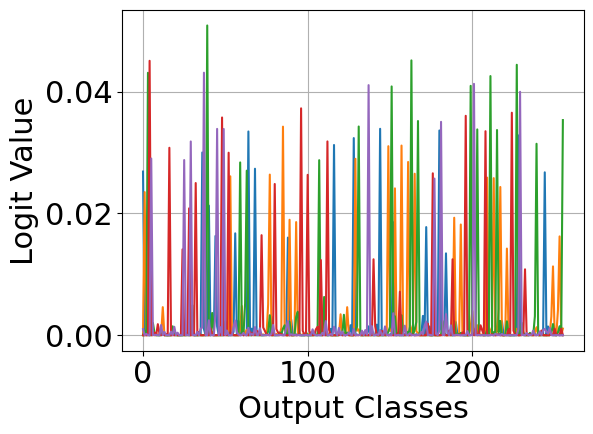

In [18]:
out_logits = []
only_reload(12)
for i in [0, 1, 3, 4, 5]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.median(logits, axis=0))
    plt.plot(out_logits[-1], label=i)
#plt.ylim([0, 0.05])
plt.grid()
#plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()
only_reload(25)
for i in [0, 1, 3, 4, 5]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.median(logits, axis=0))
    plt.plot(out_logits[-1], label=i)
#plt.ylim([0, 0.05])
plt.grid()
#plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()

## Plotting logits for each $Y_i$ as in appendix to see match

313/313 [==============================] - 0s 1ms/step


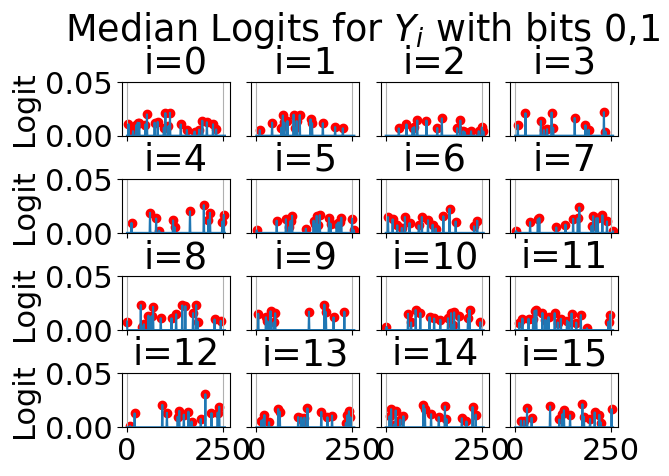

<Figure size 1600x800 with 0 Axes>

In [22]:
import numpy as np
reload_model(100)
def visualize_logits(logits, labels,list_of_stuffs=None, num_classes=256):
    """
    Visualizes the logits for each class.

    Args:
        logits (np.ndarray): Logits array of shape (num_samples, num_classes).
        labels (np.ndarray): True labels corresponding to the logits.
        num_classes (int): Number of classes in the dataset.
    """
    # Adjust the top spacing to prevent overlap with the suptitle
    fig, axs =plt.subplots(4,4)
    fig.subplots_adjust(hspace=0.8)
    fig.subplots_adjust(top=0.83)  
    avg_logits = np.zeros((num_classes, logits.shape[1]))
    for i in range(16):
        avg_logits[i] = np.median(logits[labels == i], axis=0)
        #out_logits.append(logits[9])
        axs[i//4, i%4].set_title(f"i={i}")
        axs[i//4, i%4].plot(avg_logits[i], label="Median Logits")
        axs[i//4, i%4].grid()
        axs[i//4, i%4].set_ylim([0, 0.05])
        if not list_of_stuffs is None:
            #axs[i//4, i%4].scatter(list_of_stuffs[i], avg_logits[list_of_stuffs[i]], label=f"Points $Y_{i}$", color='b')
            axs[i//4, i%4].scatter(list_of_stuffs[i], avg_logits[i][list_of_stuffs[i]], label=f"Points $Y_{i}$", color='r')
        


    for ax in axs.flat:
        ax.set(ylabel='Logit')
        # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
    fig.suptitle(f"Median Logits for $Y_i$ with bits 0,1")
    #fig.tight_layout()
    # Plot the average logits
    plt.savefig("logits_CNN.png", dpi=200)
    plt.figure(figsize=(16, 8))
    
    plt.show()

def get_class_bits(num, bits=[0,1]):
    result = 0
    for i in range(len(bits)):
        result |= ((num >> bits[i]) & 0x1) << i
    return result

def generate_logit_indices(bits=[0,1]):
    list_of_stuffs = []
    for i in range(16):
        in_sboxes = []
        out_sboxes = []
        for j in range(256):
            if get_class_bits(j, bits) == (i>>2):
                in_sboxes.append(aes_sbox[j])
            if get_class_bits(j, bits) == i %4:
                out_sboxes.append(j)
        list_of_stuffs.append(np.sort(np.intersect1d(in_sboxes, out_sboxes)))
    return list_of_stuffs

# Example usage
logits = tmp_att[-1]  # Assuming logits are in tmp_att[layer]
# Change bits here if so desired
labels = get_classes_bits(sbox_ins_att,bits=[0, 1])*4
labels += get_classes_bits(dataset.attack_labels, bits=[0, 1])
#labels = dataset.attack_labels  # Assuming labels are in dataset.attack_labels
visualize_logits(logits, labels,generate_logit_indices([0,1]))

## PCA stuff


## Testing PCA/Bit divisions quickly

313/313 [==============================] - 0s 1ms/step


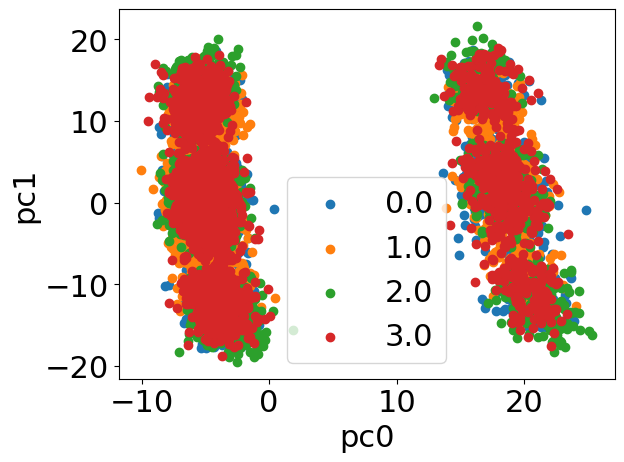

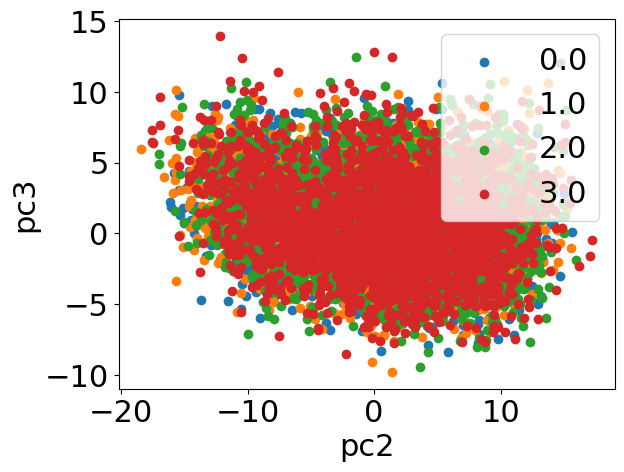

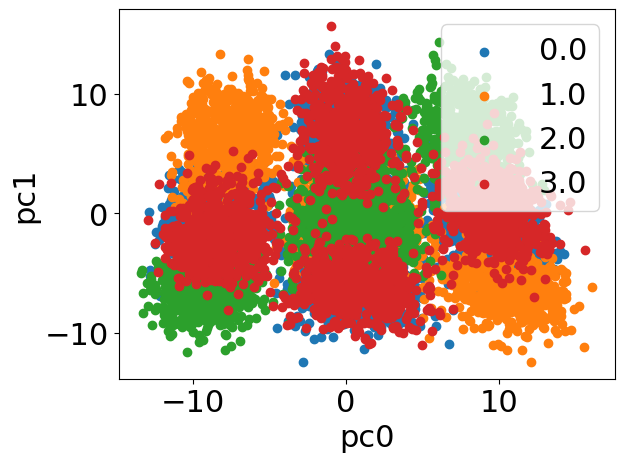

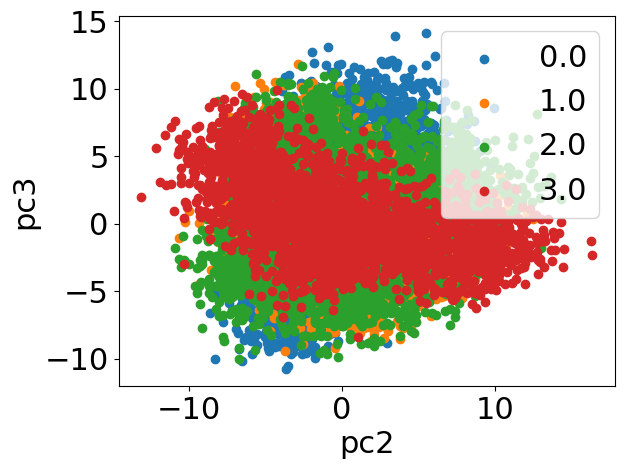

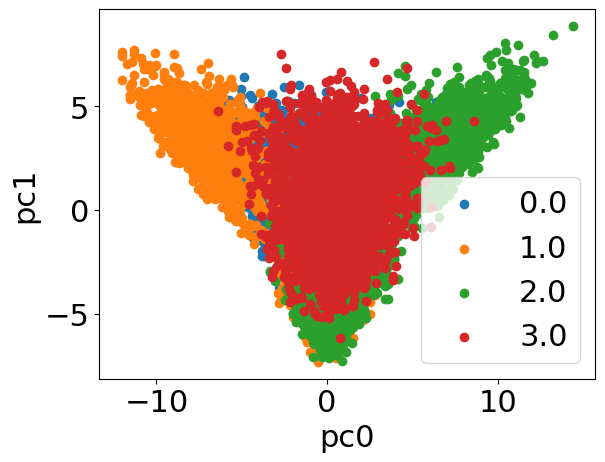

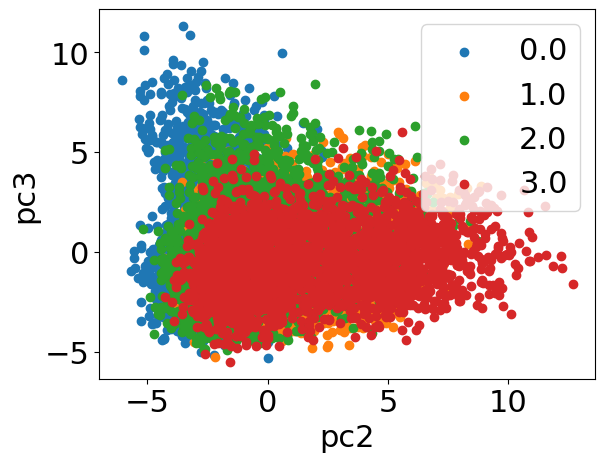

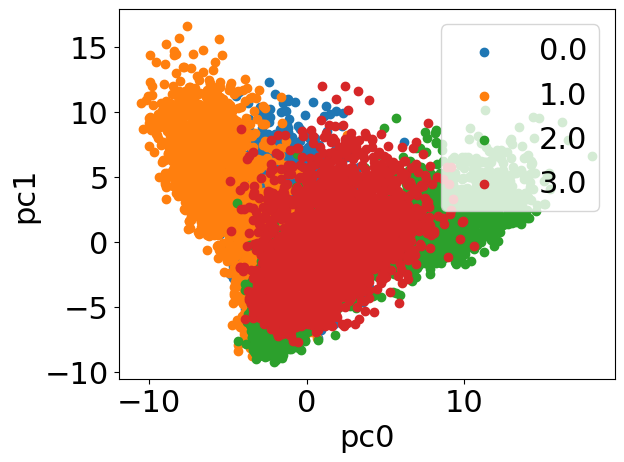

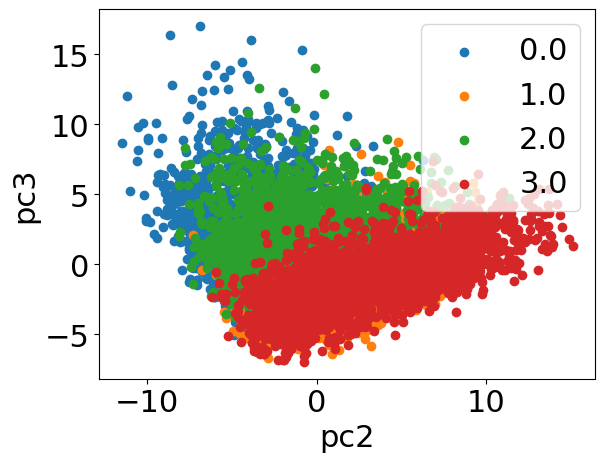

In [ ]:
from sklearn.decomposition import PCA
from utils import plot_pcs_with_class_divs, get_classes_bits
gc.collect()
reload_model(25)

for layer in range(1, 5):
    # Transforms list of values in [0,255] to classes with only 'bits' varying (0,1 for this model, varying this is ez)
    classes = get_classes_bits(sbox_ins_att, bits=[0,1])
    x_prof = tmp[layer].reshape(tmp[layer].shape[0], -1)
    x = tmp_att[layer].reshape(tmp_att[layer].shape[0], -1)
    plot_pcs_with_class_divs(x_prof, classes,n_pcs=4, activations_attack=x, pcs_to_plot=[0,1])
    classes = get_classes_bits(dataset.attack_labels, bits=[ 0, 1])
    plot_pcs_with_class_divs(x_prof, classes,n_pcs=4, activations_attack=x, pcs_to_plot=[2,3])



## Messy code for plots from paper

313/313 [==============================] - 0s 1ms/step


313/313 [==============================] - 0s 1ms/step


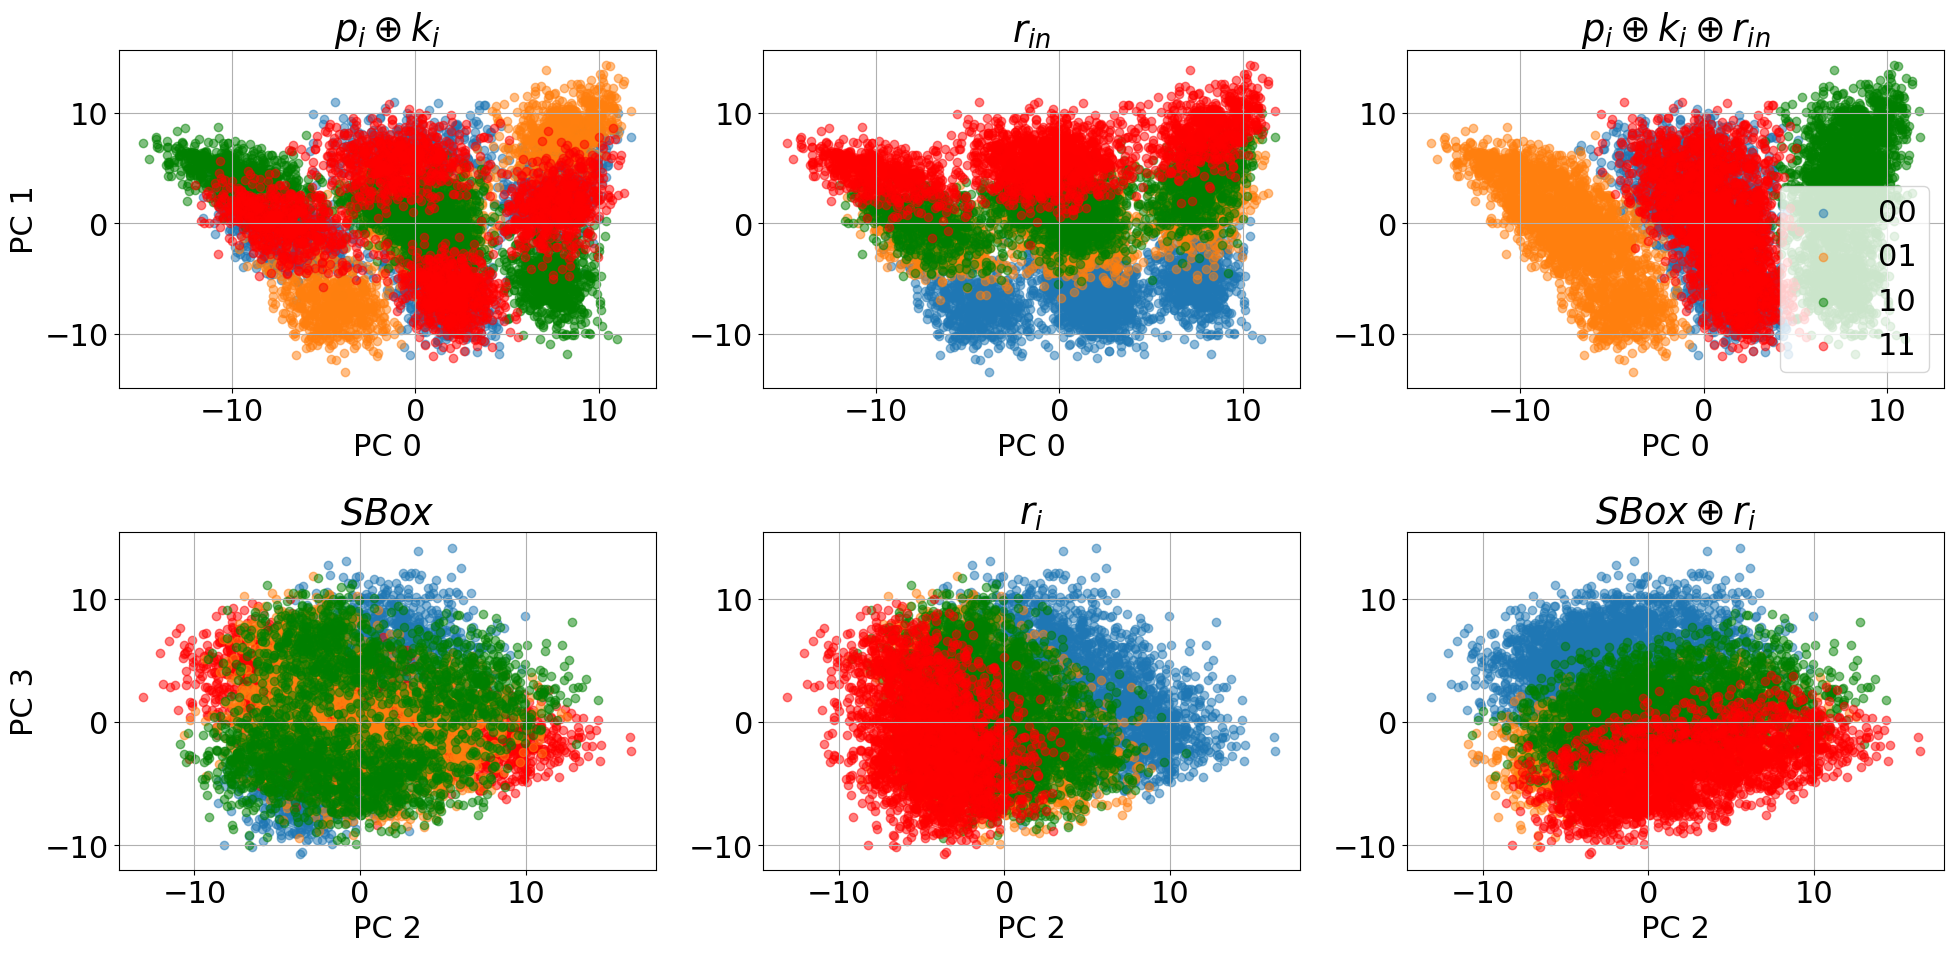

In [28]:
import gc
gc.collect()
reload_model(12)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^
                dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
font = {'size'   : 18}
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
# Prepare logits
out_logits = []
layer = 2

on = np.where(sbox_ins_att&0x3==0)
off = np.where(sbox_ins_att&0x3==1)
on2 = np.where(sbox_ins_att&0x3==2)
off3 = np.where(sbox_ins_att&0x3 ==3)
plt.figure(figsize=(20, 10))  # Adjust the figure size for 1x3 layout

labels = ["00", "01", "10", "11"]
indices_list= [on, off, on2, off3]
# Subplot 1: Logits
# PCA preparation
comp_n = 4
new_pca = PCA(n_components=comp_n)
layer = 2
new_s1_prof = new_pca.fit_transform(tmp[layer]. reshape(tmp[layer].shape[0], -1))
new_s1_att = new_pca.transform(tmp_att[layer].reshape(tmp_att[layer].shape[0], -1))

# Subplot 2: PC scatter plot for PC2 vs PC1
plt.subplot(2, 3, 1)
in1, in2 = 0, 1

plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()

plt.title("$p_i \oplus k_i$")

plt.subplot(2, 3, 2)
rin = dataset.share5_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$r_{in}$")

plt.subplot(2, 3, 3)
rin = dataset.share6_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$p_i \oplus k_i \oplus r_{in}$")
plt.legend(loc=4)
#plt.title("PCA Scatter (PC1 vs PC0)")
reload_model(25)
new_pca = PCA(n_components=comp_n)
layer = 2
new_s1_prof = new_pca.fit_transform(tmp[layer]. reshape(tmp[layer].shape[0], -1))
new_s1_att = new_pca.transform(tmp_att[layer].reshape(tmp_att[layer].shape[0], -1))

on = np.where(dataset.attack_labels&0x3==0)
off = np.where(dataset.attack_labels&0x3==1)
on2 = np.where(dataset.attack_labels&0x3==2)
off3 = np.where(dataset.attack_labels&0x3 ==3)
labels = ["00", "01", "10", "11"]
indices_list= [on, off, on2, off3]
comp_n = 4
new_pca = PCA(n_components=comp_n)
layer = 2
plt.subplot(2, 3, 4)
in1, in2 = 2, 3



plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()

plt.title("$SBox$")

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 5)
rin = dataset.share1_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$r_i$")

plt.subplot(2, 3, 6)
rin = dataset.share2_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$SBox \oplus r_i$")




# Save or show the combined plot
plt.tight_layout()
plt.savefig(f"combined_plots_ascadr_lowest_mlp.png", dpi=20)
plt.savefig(f"combined_plots_ascad_lower_mlp.png", dpi=100)
plt.savefig(f"combined_plots_ascad_mlp.png", dpi=200)
plt.show()

## Activation Patching

## Code for patching

In [31]:
# Train probes for relevant output and input classes
reload_model(25)
layer_out = -2
probe1 = train_linear_probe(tmp[layer_out], (get_classes_bits(sbox_ins, [0,1])), 5)
probe2 = train_linear_probe(tmp[layer_out], (get_classes_bits(dataset.profiling_labels, [0,1])), 5)

313/313 [==============================] - 0s 1ms/step
Epoch 1/5
250/250 [==============================] - 1s 2ms/step - loss: 0.5899 - accuracy: 0.7824
Epoch 2/5
250/250 [==============================] - 0s 2ms/step - loss: 0.2979 - accuracy: 0.8835
Epoch 3/5
250/250 [==============================] - 0s 2ms/step - loss: 0.2883 - accuracy: 0.8869
Epoch 4/5
250/250 [==============================] - 0s 2ms/step - loss: 0.2850 - accuracy: 0.8881
Epoch 5/5
250/250 [==============================] - 0s 2ms/step - loss: 0.2832 - accuracy: 0.8891
Epoch 1/5
250/250 [==============================] - 1s 2ms/step - loss: 0.9613 - accuracy: 0.5959
Epoch 2/5
250/250 [==============================] - 0s 2ms/step - loss: 0.7038 - accuracy: 0.7053
Epoch 3/5
250/250 [==============================] - 0s 2ms/step - loss: 0.6737 - accuracy: 0.7210
Epoch 4/5
250/250 [==============================] - 0s 2ms/step - loss: 0.6606 - accuracy: 0.7263
Epoch 5/5
250/250 [==============================] - 0

## SBox input patching

In [ ]:
layer=2
model_for_probe =Model(model.layers[layer+1].input, model.layers[layer_out].output)
new_pca = PCA(4)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
#fix[:, np.where(np.abs(pca.components_[0])> 0.1)[0]] = np.median(fix[np.where(new_s1_att[:, 0] < -5)[0],np.where(np.abs(pca.components_[0])> 0.1)[0]], axis=0)
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix = new_s1_att.copy()
# Rotate PCs to align
fix[:, 0] = 10#12.5

fix[:, 3] = 0
fix[:, 2] = 0

patched_preds = probe1.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masks_in = np.argmax(patched_preds, axis=1)
fix = new_s1_att.copy()
fix[:, 1] = -10#12.5
fix[:, 3] = 0
fix[:, 2] = 0

patched_preds = probe1.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
masked_in = np.argmax(patched_preds, axis=1) 

## Sbox output Patching

In [33]:
layer = 2
layer_out = -2
model_for_probe =Model(model.layers[layer+1].input, model.layers[layer_out].output)
new_pca = PCA(4)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
fix = new_s1_att.copy()
#Rotate PC2 and PC3 to align PCs with hypothesized shares to simplify patching
theta = np.radians(15)  # rotate 15 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
fix[:, 2:] = fix[:, 2:] @rot_matrix
fix[:, 2] = 12.50#12.5
#Rotate back to original position after patching
theta = np.radians(-15) 
inv_rot =  np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
fix[:, 2:] = fix[:, 2:] @inv_rot

# Set the first two PCs to zero
fix[:, 0] = 0
fix[:, 1] = 0

# Get patched predictions from the probes
patched_preds = probe2.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
sbox_out = np.argmax(patched_preds, axis=1)


# Same for other share
fix = new_s1_att.copy()
theta = np.radians(15)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 2:] = fix[:, 2:] @rot_matrix
fix[:, 3] = -9#12.5
theta = np.radians(-15) 
inv_rot =  np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
fix[:, 2:] = fix[:, 2:] @inv_rot
fix[:, 0] = 0
fix[:, 1] = 0

patched_preds = probe2.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
masked_sbox_out = np.argmax(patched_preds, axis=1) 

313/313 [==============================] - 0s 890us/step


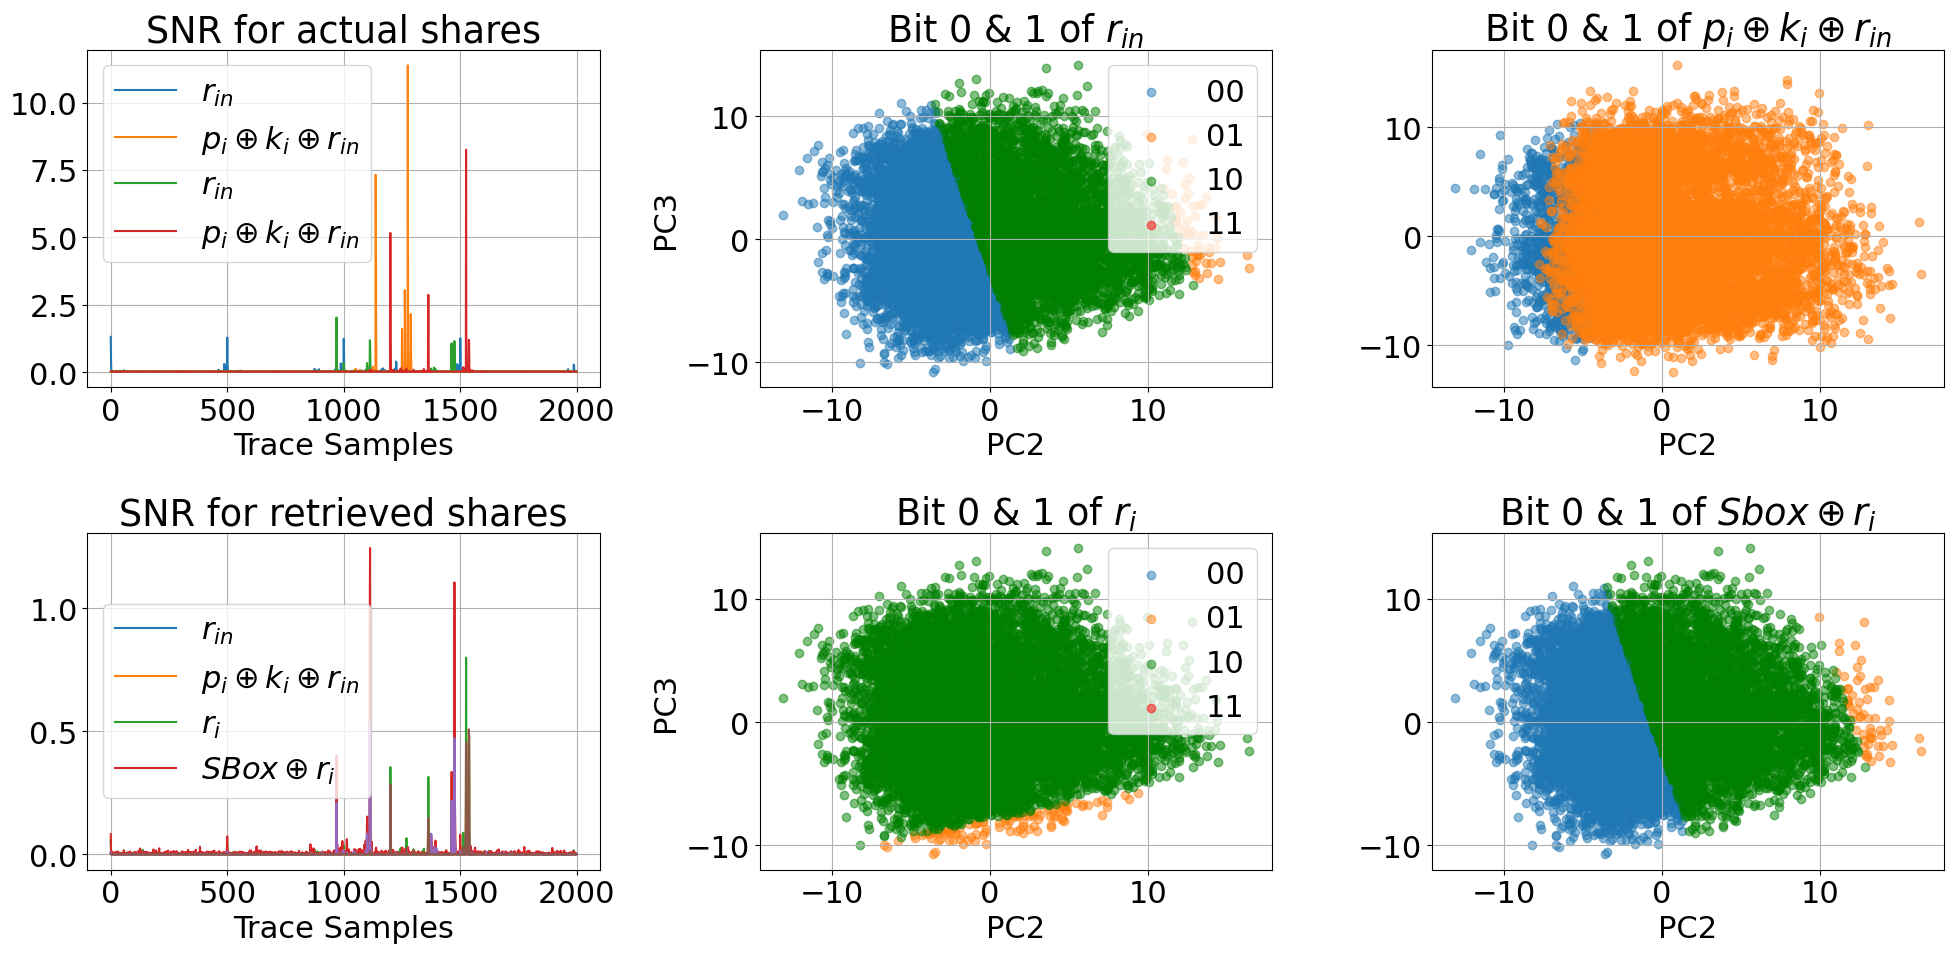

In [37]:
plt.figure(figsize=(20, 10))
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22

plt.subplot(2,3,4)

plt.plot(snr_fast(dataset.x_attack, masked_in), label="$r_{in}$")
plt.plot(snr_fast(dataset.x_attack, masks_in), label="$p_i \oplus k_i \oplus r_{in}$") 
plt.plot(snr_fast(dataset.x_attack, sbox_out), label="$r_{i}$")
plt.plot(snr_fast(dataset.x_attack, masked_sbox_out), label="$SBox \oplus r_{i}$") 
plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
plt.legend()
plt.grid()


plt.subplot(2,3,2)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.grid()
plt.title("Bit 0 & 1 of $r_{in}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

rin = masked_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=1
plt.subplot(2,3,3)
plt.xlabel(f"PC{in1}")
#plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.grid()
plt.title("Bit 0 & 1 of $p_i \oplus k_i \oplus r_{in}$")

rin = sbox_out.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=3
plt.subplot(2,3,5)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.grid()
plt.title("Bit 0 & 1 of $r_{i}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

rin = masked_sbox_out.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=3
plt.subplot(2,3,6)
plt.xlabel(f"PC{in1}")
#plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.grid()
plt.title("Bit 0 & 1 of $Sbox\oplus r_{i}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

plt.subplot(2,3,4)
plt.plot(snr_fast(dataset.x_attack, masked_in), label="$r_{i}$")
plt.plot(snr_fast(dataset.x_attack, masks_in), label="$SBox \oplus r_{i}$") 
plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
#plt.legend()
#plt.grid()

plt.subplot(2,3,1)
plt.plot(snr_fast(dataset.x_attack, dataset.share5_attack[target_byte]), label="$r_{in}$")
plt.plot(snr_fast(dataset.x_attack, dataset.share6_attack[target_byte]), label="$p_i \oplus k_i \oplus r_{in}$") 
plt.plot(snr_fast(dataset.x_attack, dataset.share1_attack[target_byte]), label="$r_{in}$")
plt.plot(snr_fast(dataset.x_attack, dataset.share2_attack[target_byte]), label="$p_i \oplus k_i \oplus r_{in}$") 
plt.title("SNR for actual shares")
plt.xlabel("Trace Samples")
plt.legend()
plt.grid()
plt.tight_layout()

# plt.savefig("patching_in_ascad.png", dpi=400)
# plt.savefig("patching_in_ascad_lower.png", dpi=100)
# plt.savefig("patching_in_ascad_lowest.same.png", dpi=50)
plt.show()